In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Parameters
INPUT_LEN = 336
OUTPUT_LEN = 48
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-4
PATIENCE = 2

# Load data
df = pd.read_csv("uk_data_clean.csv", parse_dates=["datetime"])
df = df.sort_values(["id", "datetime"])
df_grouped = df.groupby("id")
household_ids = df["id"].unique()

# Sequence function
def make_sequences(series, input_len, output_len):
    x, y = [], []
    for i in range(len(series) - input_len - output_len + 1):
        x.append(series[i:i+input_len])
        y.append(series[i+input_len:i+input_len+output_len])
    return np.array(x), np.array(y)

# Dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# LSTM Model
class LSTMForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_len=48):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_len)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Init model
model = LSTMForecast(output_len=OUTPUT_LEN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# === Training Loop ===
best_loss = float('inf')
no_improve_epochs = 0

print("Training with proportional time split (70/15/15)...")

for epoch in range(EPOCHS):
    total_loss = 0
    count = 0

    model.train()

    for hid in tqdm(household_ids):
        try:
            df_h = df_grouped.get_group(hid).copy()
            df_h = df_h.set_index("datetime")
            df_h["target"] = df_h["target"].interpolate()

            if df_h["target"].isna().sum() > 0 or len(df_h) < 500:
                continue

            values = df_h["target"].values
            n = len(values)

            train_end = int(n * 0.70)
            val_end = int(n * 0.85)

            train_series = values[:train_end]
            val_series = values[train_end:val_end]

            scaler = MinMaxScaler()
            train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
            val_scaled = scaler.transform(val_series.reshape(-1, 1)).flatten()

            X_train, y_train = make_sequences(train_scaled, INPUT_LEN, OUTPUT_LEN)
            X_val, y_val = make_sequences(val_scaled, INPUT_LEN, OUTPUT_LEN)

            if len(X_train) == 0 or len(X_val) == 0:
                continue

            train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=256)

            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * xb.size(0)
                count += xb.size(0)

        except Exception as e:
            print(f"Skipping {hid}: {e}")
            continue

    avg_loss = total_loss / count if count > 0 else float("inf")
    print(f"Epoch {epoch+1}/{EPOCHS} - Avg Training Loss: {avg_loss:.6f}")

    # Early stopping
    if avg_loss < best_loss - 1e-5:
        best_loss = avg_loss
        no_improve_epochs = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model.")
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs} epoch(s).")

    if no_improve_epochs >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Training complete.")


Using device: cuda
Training with proportional time split (70/15/15)...


100%|██████████| 919/919 [06:44<00:00,  2.27it/s]


Epoch 1/10 - Avg Training Loss: 0.008000
Saved new best model.


100%|██████████| 919/919 [05:41<00:00,  2.69it/s]


Epoch 2/10 - Avg Training Loss: 0.007521
Saved new best model.


...

Epoch 8/10 - Avg Training Loss: 0.007149
Saved new best model.


100%|██████████| 919/919 [05:28<00:00,  2.79it/s]


Epoch 9/10 - Avg Training Loss: 0.007133
Saved new best model.


100%|██████████| 919/919 [05:58<00:00,  2.56it/s]

Epoch 10/10 - Avg Training Loss: 0.007119
Saved new best model.
Training complete.


Evaluating on last 15% (test set)...


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 44.42it/s]



Test RMSE Summary:
              id      rmse
18  uk_MAC000162  0.046338
7   uk_MAC000057  0.081966
9   uk_MAC000091  0.092591
2   uk_MAC000019  0.094024
8   uk_MAC000075  0.106889


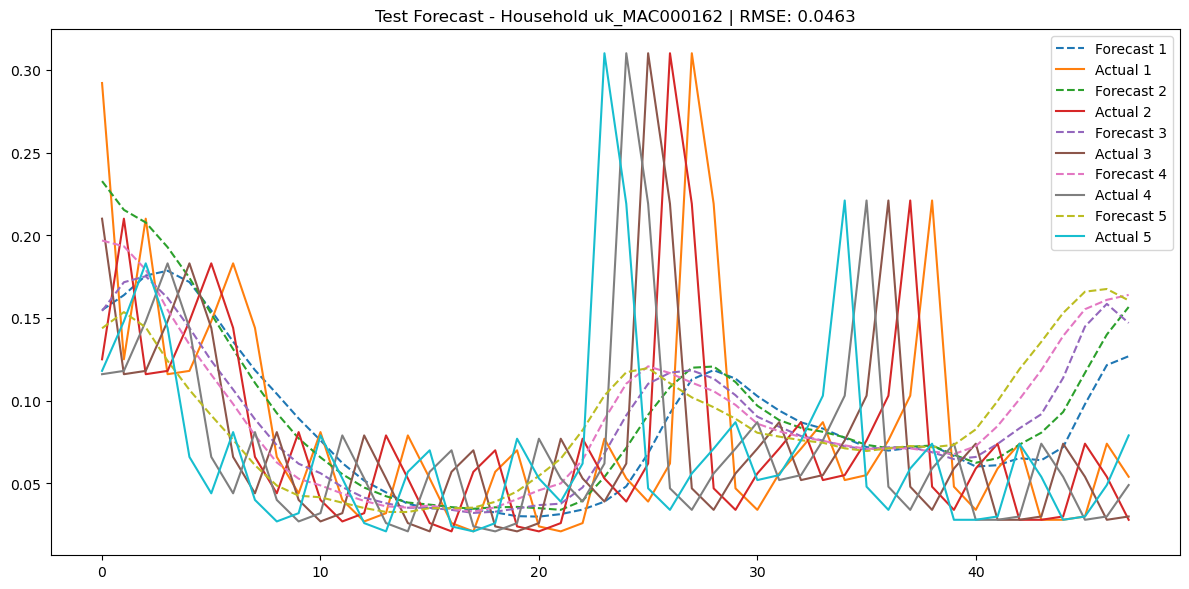

In [2]:
# === Test Evaluation ===
print("Evaluating on last 15% (test set)...")
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

results = []

for hid in tqdm(household_ids[:20]):  # limit to 20 households to reduce memory
    try:
        df_h = df_grouped.get_group(hid).copy()
        df_h = df_h.set_index("datetime")
        df_h["target"] = df_h["target"].interpolate()

        if df_h["target"].isna().sum() > 0 or len(df_h) < 500:
            continue

        values = df_h["target"].values
        n = len(values)

        train_end = int(n * 0.70)
        val_end = int(n * 0.85)
        test_series = values[val_end:]

        if len(test_series) < INPUT_LEN + OUTPUT_LEN:
            continue

        scaler = MinMaxScaler()
        scaler.fit(values[:train_end].reshape(-1, 1))  # fit on training only
        test_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

        X_test, y_test = make_sequences(test_scaled, INPUT_LEN, OUTPUT_LEN)
        if len(X_test) == 0:
            continue

        X_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
        with torch.no_grad():
            preds = model(X_tensor).cpu().numpy()

        preds_inv = scaler.inverse_transform(preds)
        y_true_inv = scaler.inverse_transform(y_test)

        rmse = np.sqrt(mean_squared_error(y_true_inv, preds_inv))

        results.append({
            "id": hid,
            "rmse": rmse,
            "forecast": preds_inv,
            "actual": y_true_inv,
        })

    except Exception as e:
        print(f"Skipping {hid} in test: {e}")
        continue

# === Summary
df_summary = pd.DataFrame([{"id": r["id"], "rmse": r["rmse"]} for r in results])
print("\nTest RMSE Summary:")
print(df_summary.sort_values("rmse").head())

# === Plot best household
if results:
    best = sorted(results, key=lambda x: x["rmse"])[0]
    plt.figure(figsize=(12, 6))
    for i in range(min(5, len(best["forecast"]))):
        plt.plot(best["forecast"][i], label=f"Forecast {i+1}", linestyle="--")
        plt.plot(best["actual"][i], label=f"Actual {i+1}")
    plt.title(f"Test Forecast - Household {best['id']} | RMSE: {best['rmse']:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.show()
